# 2 Data Visualization

In [1]:
# plot
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from highlight_text import fig_text

# data
import pandas as pd
import geopandas as gpd

In [ ]:
# world map
world = gpd.read_file("../ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

# filter on europe only
europe = world[world['CONTINENT'] == 'Europe']

In [3]:
erasmus_data = pd.read_csv("../Datasets/Processed/Erasmus-Data.csv")

C:\Users\belli\AppData\Local\Temp\ipykernel_3104\2164229321.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  erasmus_data = pd.read_csv("../Datasets/Processed/Erasmus-Data.csv")


In [4]:
erasmus_data['Sending Country'] = erasmus_data['Sending Country'].str.split(' - ').str[-1]
erasmus_data['Receiving Country'] = erasmus_data['Receiving Country'].str.split(' - ').str[-1]

erasmus_data.to_csv('../Datasets/Processed/Erasmus-Data-Renamed.csv')

## Sending Country

In [5]:
sending_counts = erasmus_data['Sending Country'].value_counts()
plot_sending_data = europe.merge(sending_counts, how='left',
                    left_on='NAME', right_on='Sending Country')

In [6]:
plot_sending_data['count'] = plot_sending_data['count'].fillna(0)

In [7]:
acc = 0
prova = []
for i in range(len(plot_sending_data['count'])):
    acc += plot_sending_data['count'][i]
for i in range(len(plot_sending_data['count'])):
    plot_sending_data['count'][i] = (plot_sending_data['count'][i] / acc)*100

C:\Users\belli\AppData\Local\Temp\ipykernel_3104\3387656278.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  plot_sending_data['count'][i] = (plot_sending_data['count'][i] / acc)*100
C:\Users\belli\AppData\Local\Temp\ipykernel_3104\338765

In [ ]:
sum(plot_sending_data['count'])

0      0.003184
1      1.021896
2     15.553658
3      1.573175
4      0.000136
5      0.219319
6      4.805030
7      2.438255
8      1.409279
9      0.000000
10     2.431717
11     1.311002
12     0.703115
13     0.464418
14    14.548023
15     0.747561
16     1.775115
17     0.029778
18     0.669407
19     0.000000
20     0.171790
21     3.451411
22     4.723997
23     3.099193
24    14.295301
25     1.287728
26    12.831413
27     1.437566
28     3.853733
29     0.123312
30     0.726863
31     1.792799
32     1.189011
33     1.180372
34     0.000000
35     0.030625
36     0.074529
37     0.009316
38     0.016972
Name: count, dtype: float64

In [9]:
# compute centroids for annotations
data_projected = plot_sending_data.to_crs(epsg=3035)
data_projected['centroid'] = data_projected.geometry.centroid
plot_sending_data['centroid'] = data_projected['centroid'].to_crs(plot_sending_data.crs)
countries_to_annotate = ['France', 'Italy', 'Romania',
                         'Lithuania', 'Finland', 'Estonia',
                         'Latvia', 'Spain', 'Germany',
                         'Sweden', 'Denmark', 'Netherlands', 'United Kingdom',
                         'Belgium', 'Austria', 'Portugal', 'Poland', 'Norway']
adjustments = {
    'France': (9, 3),
    'Italy': (-2.4, 2),
    'Lithuania': (0, -0.6),
    'Norway': (-4.5, -6.5),
    'Finland': (0, -2.5),
    'Romania': (0, -0.5),
    'Bulgaria': (0, -0.6),
    'Greece': (-1.2, -0.8),
    'Croatia': (0, -1),
    'Cyprus': (0, -1),
    'Ireland': (0, -1),
    'Malta': (0, -1),
    'Slovenia': (0, -1),
    'Slovakia': (-0.7, -0.8),
    'Estonia': (0, -0.7),
    'Latvia': (0, -0.5),
    'Belgium': (0, -0.7),
    'Austria': (0, -1),
    'Spain': (0, -1),
    'Portugal': (-0.5, -1),
    'Luxembourg': (0, -1),
    'Germany': (-0.2, 0),
    'Hungary': (-0.3, -1),
    'Czechia': (0, -1),
    'Poland': (0, -1),
    'Sweden': (-1.5, -1),
    'Denmark': (0, -1),
    'Netherlands': (0, 0),
    'United Kingdom': (0, -2),
    'Switzerland': (0, -0.5),
}

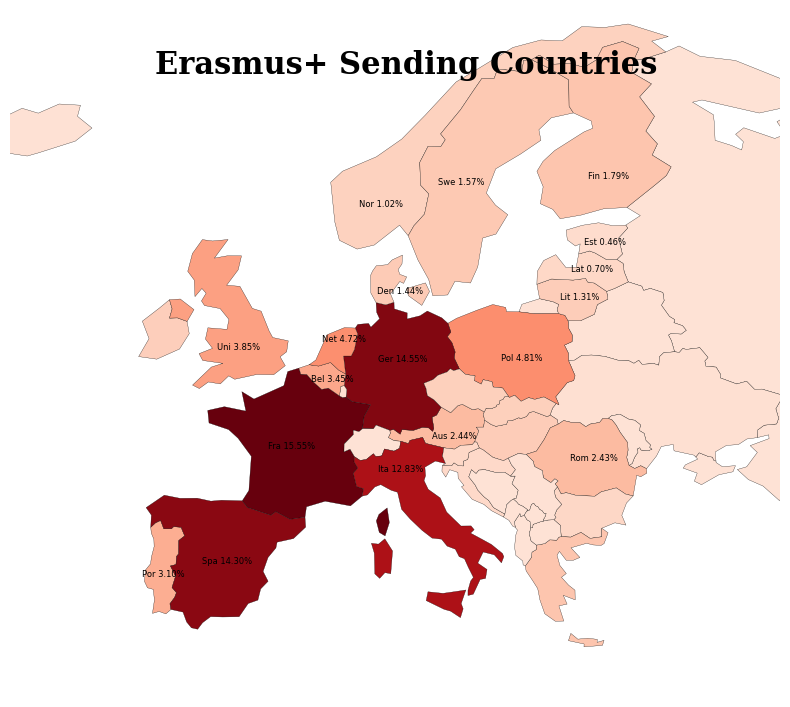

In [10]:
# initialize the figure
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# define colors
cmap = cm.Reds
min_rate, max_rate = plot_sending_data['count'].min()-2, plot_sending_data['count'].max()
norm = mcolors.Normalize(vmin=min_rate, vmax=max_rate)

# create the plot
plot_sending_data.plot(column='count', cmap=cmap, norm=norm,
          edgecolor='black', linewidth=0.2, ax=ax)

# custom axis
ax.set_xlim(-20, 40)
ax.set_ylim(32, 72)
ax.axis('off')

# add a title
fig.text(0.2, 0.85, 'Erasmus+ Sending Countries', fontsize=22, fontweight='bold', fontfamily='serif')

# annotate countries
for country in countries_to_annotate:

    # get centroid
    centroid = plot_sending_data.loc[plot_sending_data['NAME'] == country, 'centroid'].values[0]
    x, y = centroid.coords[0]

    # get corrections
    x += adjustments[country][0]
    y += adjustments[country][1]

    # get rate and annotate
    rate = plot_sending_data.loc[plot_sending_data['NAME'] == country, 'count'].values[0]
    ax.annotate(f'{country[:3]} {rate:.2f}%', (x, y), textcoords="offset points", xytext=(5, 5),
                ha='center', fontsize=6, fontfamily='DejaVu Sans', color='black')


# display the plot
plt.tight_layout()
plt.show()

## Receiving Country

In [11]:
receiving_counts = erasmus_data['Receiving Country'].value_counts()
plot_receiving_data = europe.merge(receiving_counts, how='left',
                    left_on='NAME', right_on='Receiving Country')

In [12]:
plot_receiving_data['count'] = plot_receiving_data['count'].fillna(0)

In [13]:
acc = 0
prova = []
for i in range(len(plot_receiving_data['count'])):
    acc += plot_receiving_data['count'][i]
for i in range(len(plot_receiving_data['count'])):
    plot_receiving_data['count'][i] = (plot_receiving_data['count'][i] / acc)*100

C:\Users\belli\AppData\Local\Temp\ipykernel_3104\1969552892.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  plot_receiving_data['count'][i] = (plot_receiving_data['count'][i] / acc)*100
C:\Users\belli\AppData\Local\Temp\ipykernel_3104\19

In [14]:
plot_receiving_data['count']

0      0.001859
1      2.484625
2      9.456664
3      3.440363
4      0.000000
5      0.000764
6      5.145203
7      2.858081
8      1.980010
9      0.000000
10     1.194514
11     1.086332
12     0.613826
13     0.614955
14    10.438800
15     0.466197
16     1.675952
17     0.017134
18     0.812591
19     0.148160
20     0.429705
21     4.150981
22     4.542966
23     5.139193
24    15.975224
25     2.480176
26     9.568797
27     1.962013
28     7.025565
29     0.298977
30     0.937906
31     2.736584
32     0.683357
33     1.516436
34     0.000000
35     0.033869
36     0.072586
37     0.004084
38     0.005545
Name: count, dtype: float64

In [15]:
# compute centroids for annotations
data_projected = plot_receiving_data.to_crs(epsg=3035)
data_projected['centroid'] = data_projected.geometry.centroid
plot_receiving_data['centroid'] = data_projected['centroid'].to_crs(plot_receiving_data.crs)
countries_to_annotate = ['France', 'Italy', 'Romania',
                         'Lithuania', 'Finland', 'Estonia',
                         'Latvia', 'Spain', 'Germany',
                         'Sweden', 'Denmark', 'Netherlands', 'United Kingdom',
                         'Belgium', 'Austria', 'Portugal', 'Poland', 'Norway']
adjustments = {
    'France': (9, 3),
    'Italy': (-2.4, 2),
    'Lithuania': (0, -0.6),
    'Norway': (-4.5, -6.5),
    'Finland': (0, -2.5),
    'Romania': (0, -0.5),
    'Bulgaria': (0, -0.6),
    'Greece': (-1.2, -0.8),
    'Croatia': (0, -1),
    'Cyprus': (0, -1),
    'Ireland': (0, -1),
    'Malta': (0, -1),
    'Slovenia': (0, -1),
    'Slovakia': (-0.7, -0.8),
    'Estonia': (0, -0.7),
    'Latvia': (0, -0.5),
    'Belgium': (0, -0.7),
    'Austria': (0, -1),
    'Spain': (0, -1),
    'Portugal': (-0.5, -1),
    'Luxembourg': (0, -1),
    'Germany': (-0.2, 0),
    'Hungary': (-0.3, -1),
    'Czechia': (0, -1),
    'Poland': (0, -1),
    'Sweden': (-1.5, -1),
    'Denmark': (0, -1),
    'Netherlands': (0, 0),
    'United Kingdom': (0, -2),
    'Switzerland': (0, -0.5),
}

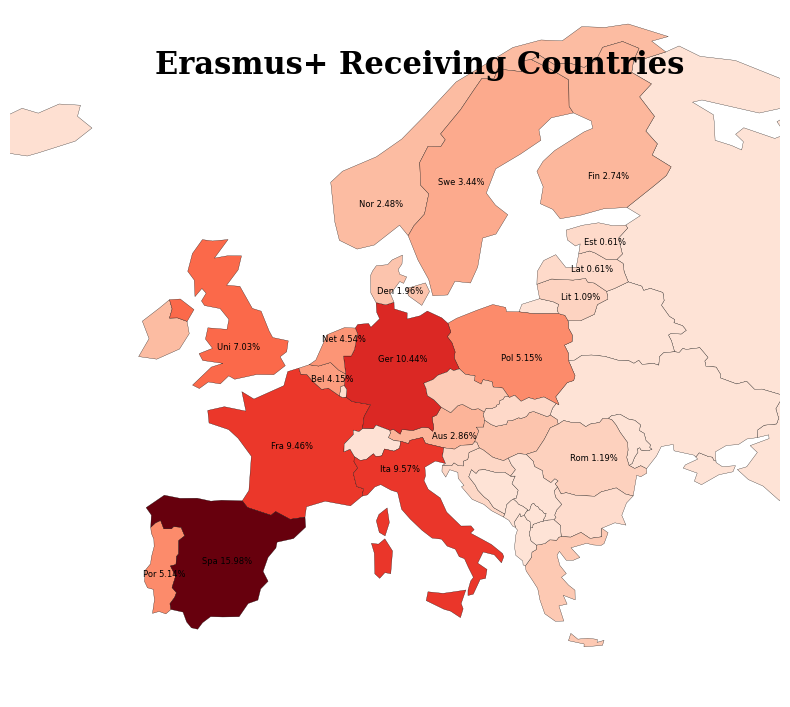

In [16]:
# initialize the figure
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# define colors
cmap = cm.Reds
min_rate, max_rate = plot_receiving_data['count'].min()-2, plot_receiving_data['count'].max()
norm = mcolors.Normalize(vmin=min_rate, vmax=max_rate)

# create the plot
plot_receiving_data.plot(column='count', cmap=cmap, norm=norm,
          edgecolor='black', linewidth=0.2, ax=ax)

# custom axis
ax.set_xlim(-20, 40)
ax.set_ylim(32, 72)
ax.axis('off')

# add a title
fig.text(0.2, 0.85, 'Erasmus+ Receiving Countries', fontsize=22, fontweight='bold', fontfamily='serif')

# annotate countries
for country in countries_to_annotate:

    # get centroid
    centroid = plot_receiving_data.loc[plot_receiving_data['NAME'] == country, 'centroid'].values[0]
    x, y = centroid.coords[0]

    # get corrections
    x += adjustments[country][0]
    y += adjustments[country][1]

    # get rate and annotate
    rate = plot_receiving_data.loc[plot_receiving_data['NAME'] == country, 'count'].values[0]
    ax.annotate(f'{country[:3]} {rate:.2f}%', (x, y), textcoords="offset points", xytext=(5, 5),
                ha='center', fontsize=6, fontfamily='DejaVu Sans', color='black')


# display the plot
plt.tight_layout()
plt.show()